# ndev-morphology API Demo

This notebook demonstrates the core API of `ndev-morphology` for skeleton analysis of neuronal and branching structures.

## Features Demonstrated:
1. **Skeleton operations**: `skeletonize_labels`, `exclude_region_from_skeleton`, `filter_labels_by_size`
2. **Branch analysis**: `create_skeleton`, `summarize_branches` using skan
3. **Sholl analysis**: `compute_sholl_profile` for quantifying branching complexity
4. **napari visualization**: Display skeletons as Shapes layers with property coloring

## Data Source
We use the `neuron-4Ch.tiff` sample from `ndev-sampledata`, which contains:
- Channel 0: NCOA4
- Channel 1: Ferritin  
- Channel 2: Phalloidin (actin cytoskeleton)
- Channel 3: DAPI (nuclei)

## 1. Setup and Configuration

In [1]:
# Core imports

import matplotlib.pyplot as plt
import napari
import numpy as np
from bioio import BioImage

# napari visualization
from ndev_morphology.napari import (
    add_sholl_to_viewer,
    add_skeleton_to_viewer,
    sholl_shells_to_shapes,
    skeleton_to_paths,
)

# Sample data
from ndev_sampledata._sample_data import sample_dir

# Image processing
from skimage import filters, measure, morphology

# ndev-morphology API
from ndev_morphology import (
    compute_sholl_profile,
    create_skeleton,
    exclude_region_from_skeleton,
    filter_labels_by_size,
    skeletonize_labels,
    summarize_branches,
)

# Configure matplotlib
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'gray'

## 2. Load Sample Data

Load a neuron image from `ndev-sampledata`.

In [2]:
# Load neuron sample data
neuron_path = sample_dir / "neuron-4Ch.tiff"
img = BioImage(neuron_path)

# Get pixel spacing for real-world measurements
spacing = (img.physical_pixel_sizes.Y, img.physical_pixel_sizes.X)
print(f"Image shape: {img.shape}")
print(f"Channel names: {img.channel_names}")
print(f"Pixel spacing (Y, X): {spacing} µm")

# Extract Phalloidin channel (actin cytoskeleton) - best for morphology
phalloidin = img.get_image_data("YX", C=2)

# Extract DAPI channel (nuclei) - for soma exclusion
dapi = img.get_image_data("YX", C=3)

print(f"\nPhalloidin shape: {phalloidin.shape}")
print(f"DAPI shape: {dapi.shape}")

Image shape: (1, 4, 1, 623, 502)
Channel names: [np.str_('AF647'), np.str_('AF568'), np.str_('AF488'), np.str_('DAPI')]
Pixel spacing (Y, X): (0.1241, 0.1241) µm

Phalloidin shape: (623, 502)
DAPI shape: (623, 502)


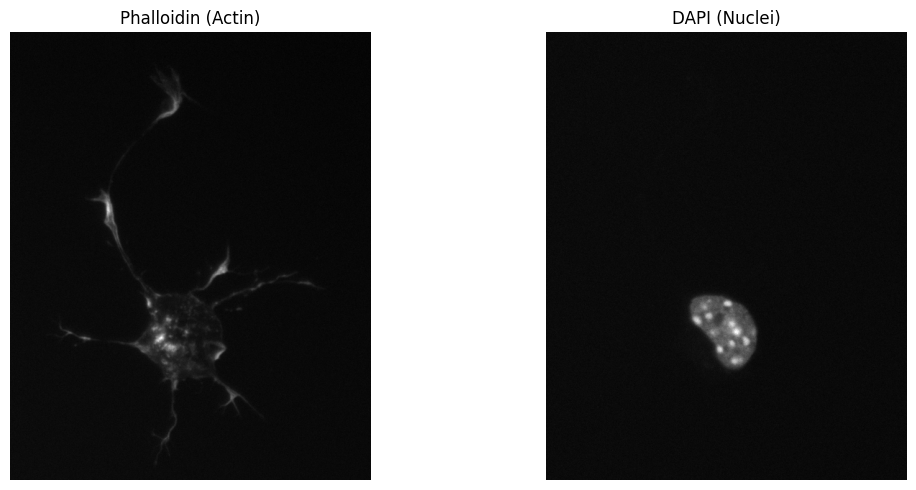

In [3]:
# Visualize raw data
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(phalloidin)
axes[0].set_title('Phalloidin (Actin)')
axes[0].axis('off')

axes[1].imshow(dapi)
axes[1].set_title('DAPI (Nuclei)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 3. Create Labels and Skeleton

First, we'll threshold the Phalloidin image to create a binary mask, then create labeled regions and skeletonize them.

Number of labeled regions: 12


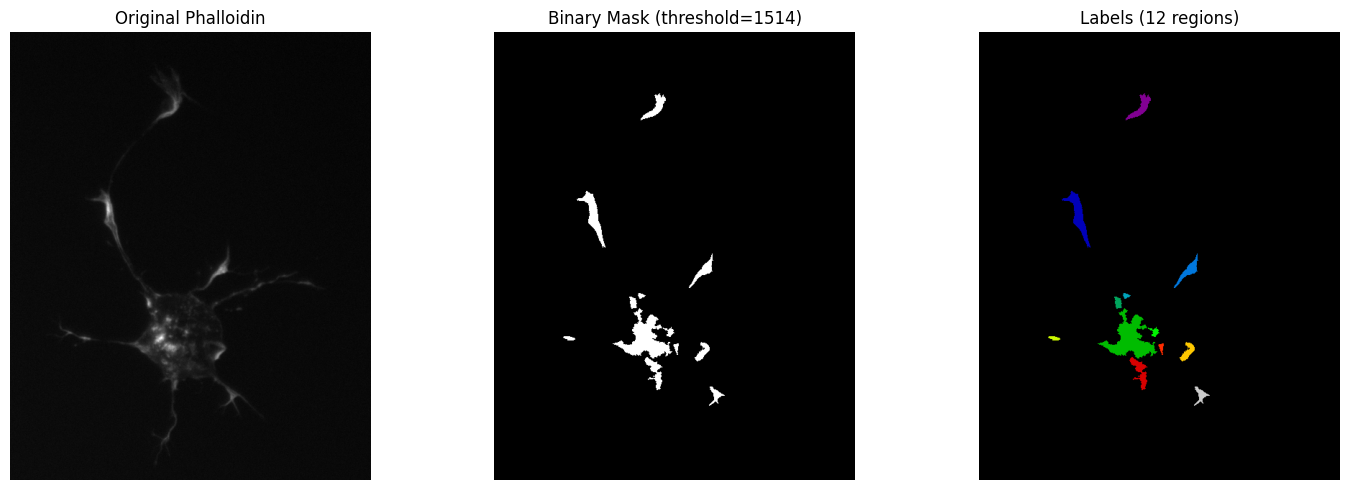

In [4]:
# Threshold the Phalloidin image to create binary mask
threshold = filters.threshold_otsu(phalloidin)
binary_mask = phalloidin > threshold

# Clean up with morphological operations
binary_clean = morphology.remove_small_objects(binary_mask, min_size=50)
binary_clean = morphology.remove_small_holes(binary_clean, area_threshold=100)

# Label connected components
labels = measure.label(binary_clean)
print(f"Number of labeled regions: {labels.max()}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(phalloidin)
axes[0].set_title('Original Phalloidin')
axes[0].axis('off')

axes[1].imshow(binary_clean)
axes[1].set_title(f'Binary Mask (threshold={threshold:.0f})')
axes[1].axis('off')

axes[2].imshow(labels, cmap='nipy_spectral')
axes[2].set_title(f'Labels ({labels.max()} regions)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Original labels unique values: [0 1 2 3 4 5 6 7 8 9]...
Skeleton labels unique values: [0 1 2 3 4 5 6 7 8 9]...
Skeleton pixels: 728


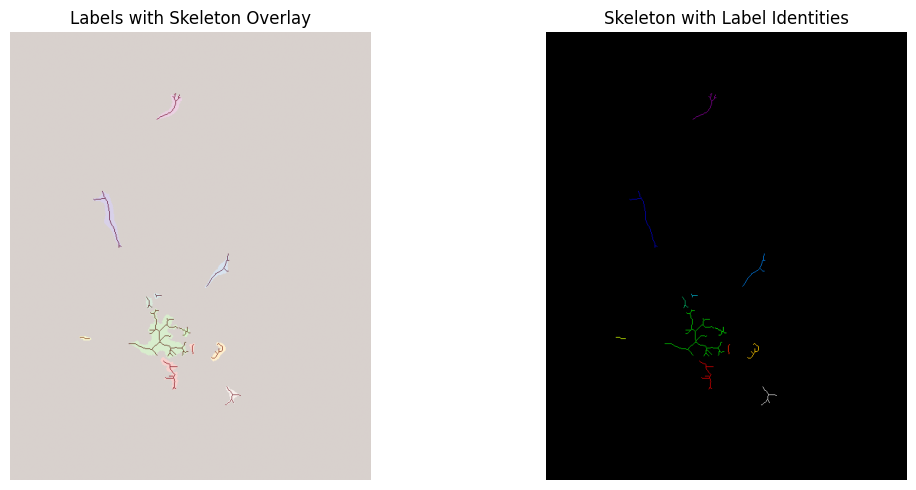

In [5]:
# Use ndev-morphology's skeletonize_labels to create skeleton with label identities
skeleton_labels = skeletonize_labels(labels)

print(f"Original labels unique values: {np.unique(labels)[:10]}...")
print(f"Skeleton labels unique values: {np.unique(skeleton_labels)[:10]}...")
print(f"Skeleton pixels: {np.count_nonzero(skeleton_labels)}")

# Visualize skeleton overlay
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Show labels with skeleton overlay
axes[0].imshow(labels, cmap='nipy_spectral', alpha=0.5)
axes[0].imshow(skeleton_labels > 0, cmap='Reds', alpha=0.7)
axes[0].set_title('Labels with Skeleton Overlay')
axes[0].axis('off')

# Show skeleton alone
axes[1].imshow(skeleton_labels, cmap='nipy_spectral')
axes[1].set_title('Skeleton with Label Identities')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 4. Branch Analysis with skan

Use `create_skeleton` and `summarize_branches` to analyze the skeleton topology.

In [6]:
# Create a binary skeleton for skan analysis
binary_skeleton = skeleton_labels > 0

# Create skan Skeleton object with physical spacing
skel = create_skeleton(binary_skeleton, spacing=spacing)

print(f"Number of skeleton paths: {skel.n_paths}")
print(f"Spacing used: {skel.spacing}")

# Get branch summary as DataFrame
branch_df = summarize_branches(skel)
print(f"\nBranch DataFrame shape: {branch_df.shape}")
print(f"Columns: {branch_df.columns.tolist()}")

# Display first few branches
branch_df.head(10)

Number of skeleton paths: 83
Spacing used: [0.1241 0.1241]

Branch DataFrame shape: (83, 16)
Columns: ['skeleton_id', 'node_id_src', 'node_id_dst', 'branch_distance', 'branch_type', 'mean_pixel_value', 'stdev_pixel_value', 'image_coord_src_0', 'image_coord_src_1', 'image_coord_dst_0', 'image_coord_dst_1', 'coord_src_0', 'coord_src_1', 'coord_dst_0', 'coord_dst_1', 'euclidean_distance']


,skeleton_id,node_id_src,node_id_dst,branch_distance,branch_type,mean_pixel_value,stdev_pixel_value,image_coord_src_0,image_coord_src_1,image_coord_dst_0,image_coord_dst_1,coord_src_0,coord_src_1,coord_dst_0,coord_dst_1,euclidean_distance
0,0,0,3,0.299604,1,1.0,0.0,85,230,87,229,10.5485,28.5430,10.7967,28.4189,0.277496
1,0,1,3,0.175504,1,1.0,0.0,86,228,87,229,10.6726,28.2948,10.7967,28.4189,0.175504
2,0,3,11,0.423704,2,1.0,0.0,87,229,90,228,10.7967,28.4189,11.1690,28.2948,0.392439
3,0,4,14,0.547804,1,1.0,0.0,87,235,91,234,10.7967,29.1635,11.2931,29.0394,0.511677
4,0,7,11,0.299604,1,1.0,0.0,89,226,90,228,11.0449,28.0466,11.1690,28.2948,0.277496
5,0,11,23,0.723308,2,1.0,0.0,90,228,95,230,11.1690,28.2948,11.7895,28.5430,0.668299
6,0,14,16,0.248200,1,1.0,0.0,91,234,91,236,11.2931,29.0394,11.2931,29.2876,0.248200
7,0,14,23,0.774712,2,1.0,0.0,91,234,95,230,11.2931,29.0394,11.7895,28.5430,0.702016
8,0,23,59,5.217366,1,1.0,0.0,95,230,121,204,11.7895,28.5430,15.0161,25.3164,4.563101
9,1,60,75,1.446616,1,1.0,0.0,221,128,231,132,27.4261,15.8848,28.6671,16.3812,1.336598


Branch Statistics (in physical units):
  Total branches: 83
  Mean branch length: 1.23 µm
  Median branch length: 0.80 µm
  Max branch length: 9.17 µm
  Total skeleton length: 102.14 µm

Branch Type Distribution:
  endpoint-endpoint: 2
  junction-endpoint: 54
  junction-junction: 27


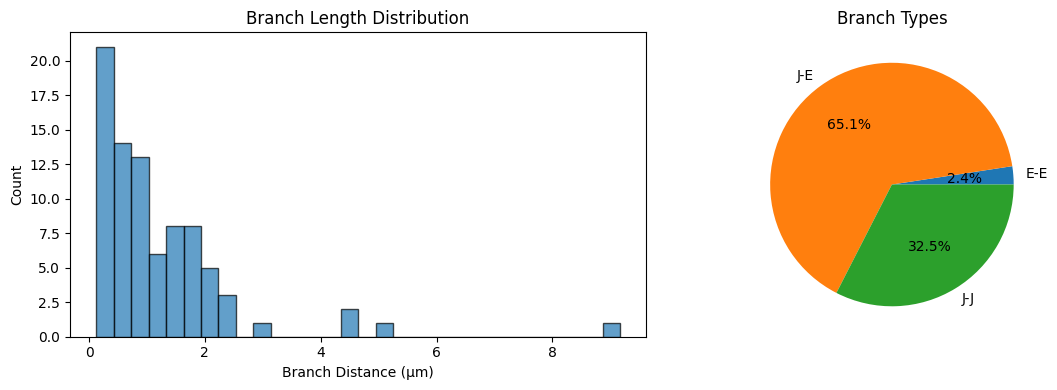

In [7]:
# Analyze branch statistics
print("Branch Statistics (in physical units):")
print(f"  Total branches: {len(branch_df)}")
print(f"  Mean branch length: {branch_df['branch_distance'].mean():.2f} µm")
print(f"  Median branch length: {branch_df['branch_distance'].median():.2f} µm")
print(f"  Max branch length: {branch_df['branch_distance'].max():.2f} µm")
print(f"  Total skeleton length: {branch_df['branch_distance'].sum():.2f} µm")

# Branch type distribution
# 0 = endpoint-to-endpoint, 1 = junction-to-endpoint, 2 = junction-to-junction
branch_types = {0: 'endpoint-endpoint', 1: 'junction-endpoint', 2: 'junction-junction'}
print("\nBranch Type Distribution:")
for btype, name in branch_types.items():
    count = (branch_df['branch_type'] == btype).sum()
    print(f"  {name}: {count}")

# Plot branch length distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(branch_df['branch_distance'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Branch Distance (µm)')
axes[0].set_ylabel('Count')
axes[0].set_title('Branch Length Distribution')

# Branch type pie chart
type_counts = [
    (branch_df['branch_type'] == 0).sum(),
    (branch_df['branch_type'] == 1).sum(),
    (branch_df['branch_type'] == 2).sum()
]
axes[1].pie(type_counts, labels=['E-E', 'J-E', 'J-J'], autopct='%1.1f%%')
axes[1].set_title('Branch Types')

plt.tight_layout()
plt.show()

## 5. Sholl Analysis

Perform Sholl analysis to quantify branching complexity from a center point. This counts skeleton crossings at concentric circles.

In [8]:
# Find a center point for Sholl analysis
# Use centroid of DAPI (nucleus) if available, otherwise image center
if dapi.max() > 0:
    # Threshold DAPI and find centroid
    dapi_binary = dapi > filters.threshold_otsu(dapi)
    dapi_props = measure.regionprops(measure.label(dapi_binary))
    if dapi_props:
        # Use largest nucleus centroid
        largest = max(dapi_props, key=lambda x: x.area)
        center_px = np.array(largest.centroid)  # (Y, X) in pixels
    else:
        center_px = np.array([dapi.shape[0] / 2, dapi.shape[1] / 2])
else:
    center_px = np.array([phalloidin.shape[0] / 2, phalloidin.shape[1] / 2])

# Convert to physical units for Sholl analysis
center_um = center_px * np.array(spacing)

print(f"Center point (pixels): {center_px}")
print(f"Center point (µm): {center_um}")

# Define Sholl radii (in µm)
max_radius = min(phalloidin.shape) * min(spacing) * 0.4  # 40% of image
radii = np.arange(1, max_radius, 1)  # 1 µm step
print(f"Sholl radii: {radii[0]:.1f} to {radii[-1]:.1f} µm, step=1 µm")

Center point (pixels): [411.72027856 249.44818438]
Center point (µm): [51.09448657 30.95651968]
Sholl radii: 1.0 to 24.0 µm, step=1 µm


In [9]:
# Perform Sholl analysis
sholl_result = compute_sholl_profile(
    skel,
    center=center_um,
    radii=radii,
)

# Print summary statistics
print("Sholl Analysis Results:")
print(f"  Max crossings: {sholl_result.max_crossings}")
print(f"  Critical radius: {sholl_result.critical_radius:.2f} µm")
print(f"  Enclosing radius: {sholl_result.enclosing_radius:.2f} µm")
print(f"  Mean crossings: {sholl_result.mean_crossings:.2f}")
print(f"  Total crossings: {sholl_result.total_crossings}")

# Convert to dict for easy DataFrame integration
print(f"\nAs dict: {sholl_result.to_dict()}")

Sholl Analysis Results:
  Max crossings: 9
  Critical radius: 4.00 µm
  Enclosing radius: 24.00 µm
  Mean crossings: 2.33
  Total crossings: 56

As dict: {'center': [51.09448656939148, 30.95651968164484], 'max_crossings': 9, 'critical_radius': 4.0, 'enclosing_radius': 24.0, 'mean_crossings': 2.3333333333333335, 'total_crossings': 56}


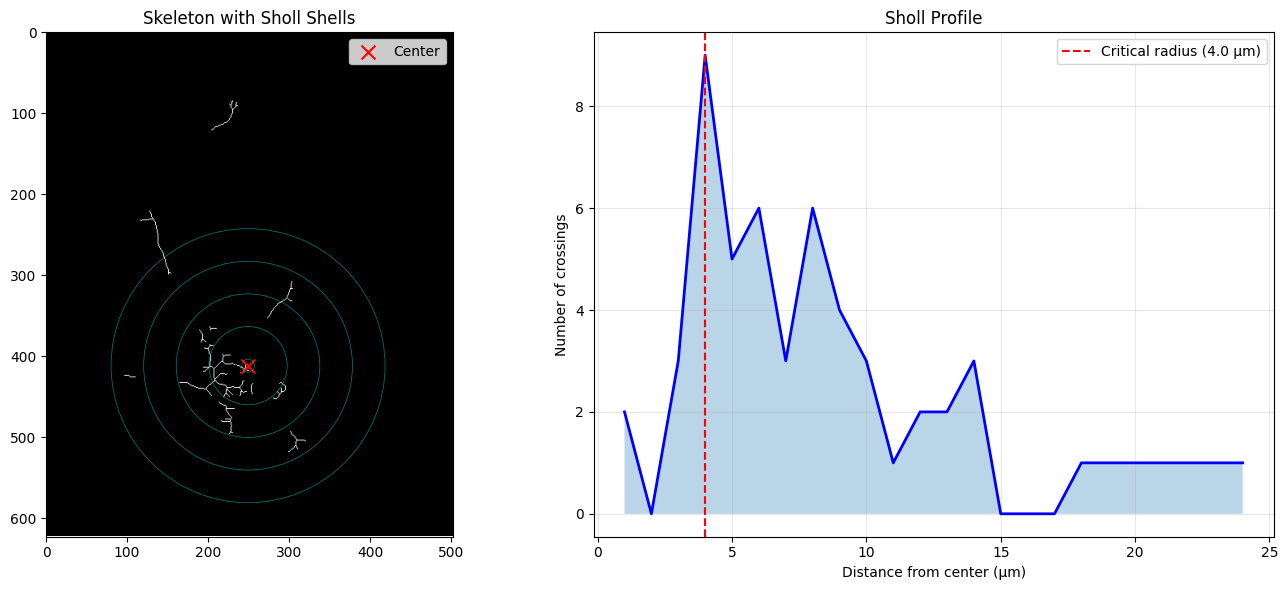

In [10]:
# Visualize Sholl analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Skeleton with Sholl shells
ax = axes[0]
ax.imshow(binary_skeleton, cmap='gray')
ax.scatter(center_px[1], center_px[0], c='red', s=100, marker='x', label='Center')

# Draw Sholl shells (convert µm back to pixels)
for i, r in enumerate(radii[::5]):  # Every 5th radius
    r_px = r / spacing[0]  # Convert to pixels
    circle = plt.Circle((center_px[1], center_px[0]), r_px,
                        fill=False, color='cyan', alpha=0.5, linewidth=0.5)
    ax.add_patch(circle)

ax.set_title('Skeleton with Sholl Shells')
ax.legend()
ax.set_xlim(0, binary_skeleton.shape[1])
ax.set_ylim(binary_skeleton.shape[0], 0)
ax.set_aspect('equal')

# Right: Sholl profile
ax = axes[1]
ax.plot(sholl_result.radii, sholl_result.counts, 'b-', linewidth=2)
ax.axvline(sholl_result.critical_radius, color='red', linestyle='--',
           label=f'Critical radius ({sholl_result.critical_radius:.1f} µm)')
ax.fill_between(sholl_result.radii, sholl_result.counts, alpha=0.3)
ax.set_xlabel('Distance from center (µm)')
ax.set_ylabel('Number of crossings')
ax.set_title('Sholl Profile')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. napari Visualization

The key feature of `ndev-morphology` is interactive skeleton visualization in napari using **Shapes layers**.

This approach (from [skan documentation](https://skeleton-analysis.org/stable/examples/visualizing_3d_skeletons.html)):
- Represents each skeleton branch as a **path** in a Shapes layer
- Allows **property-based coloring** (e.g., color by branch length, skeleton ID)
- Works in **2D and 3D**
- Enables **interactive inspection** of individual branches

In [11]:
# Get skeleton paths and properties for napari Shapes layer
paths, props = skeleton_to_paths(skel)

print(f"Number of skeleton paths: {len(paths)}")
print("Properties available for coloring:")
for col in props.columns:
    if props[col].dtype in [np.float64, np.int64, int, float]:
        print(f"  - {col}: {props[col].min():.2f} to {props[col].max():.2f}")

print(f"\nExample: First path has {len(paths[0])} coordinate points")
print(f"First path coordinates (first 3 points):\n{paths[0][:3]}")

Number of skeleton paths: 83
Properties available for coloring:
  - branch_distance: 0.12 to 9.17
  - branch_type: 0.00 to 2.00
  - mean_pixel_value: 1.00 to 1.00
  - stdev_pixel_value: 0.00 to 0.00
  - image_coord_src_0: 85.00 to 511.00
  - image_coord_src_1: 97.00 to 309.00
  - image_coord_dst_0: 87.00 to 518.00
  - image_coord_dst_1: 110.00 to 320.00
  - coord_src_0: 10.55 to 63.42
  - coord_src_1: 12.04 to 38.35
  - coord_dst_0: 10.80 to 64.28
  - coord_dst_1: 13.65 to 39.71
  - euclidean_distance: 0.12 to 8.52
  - path_id: 0.00 to 82.00

Example: First path has 3 coordinate points
First path coordinates (first 3 points):
[[ 85 230]
 [ 86 230]
 [ 87 229]]


In [12]:
# Generate Sholl shell shapes for napari visualization
# Convert from physical units back to pixels for display
center_px_display = center_px  # Already in pixels
radii_px = sholl_result.radii / spacing[0]  # Convert radii from µm to pixels

shells = sholl_shells_to_shapes(center_px_display, radii_px, n_points=64, ndim=2)

print(f"Generated {len(shells)} Sholl shells")
print(f"Radii range: {radii_px.min():.1f} to {radii_px.max():.1f} pixels")
print(f"Each shell is a polygon with {shells[0].shape[0]} vertices")

Generated 24 Sholl shells
Radii range: 8.1 to 193.4 pixels
Each shell is a polygon with 64 vertices


In [ ]:

viewer = napari.Viewer()

# Add original intensity image
viewer.add_image(phalloidin, name='Phalloidin', colormap='magenta')

# Add skeleton visualization
add_skeleton_to_viewer(viewer, skel, name='Skeleton (by length)',
                      edge_color='branch_distance', edge_colormap='viridis')

# Add Sholl analysis shells
add_sholl_to_viewer(viewer, sholl_result, spacing=spacing, name='Sholl Shells')

napari.run()

### Manual napari Shapes layer creation

For more control, you can create the Shapes layers manually using the raw `paths` and `props` data:

In [ ]:
# Example: Code snippet for manual Shapes layer creation in standalone script
# This shows how to use the underlying napari API pattern from skan docs
#
# === IN A STANDALONE SCRIPT (e.g., visualize_advanced.py): ===
#
# import napari
# from ndev_morphology.napari import skeleton_to_paths, sholl_shells_to_shapes
#
# viewer = napari.Viewer()
#
# # Get paths and properties
# all_paths, all_props = skeleton_to_paths(skel)
#
# # Filter: only junction-to-junction branches
# j2j_mask = all_props['branch_type'] == 2
# j2j_paths = [p for p, m in zip(all_paths, j2j_mask) if m]
# j2j_props = all_props[j2j_mask].reset_index(drop=True)
#
# if len(j2j_paths) > 0:
#     viewer.add_shapes(
#         j2j_paths,
#         shape_type='path',
#         properties=j2j_props,
#         edge_color='euclidean_distance',
#         edge_colormap='plasma',
#         edge_width=3,
#         name='Junction-Junction branches',
#     )
#
# # Color shells by crossing count
# active_shells = [s for s, c in zip(shells, sholl_result.counts) if c > 0]
# active_props = {'crossings': sholl_result.counts[sholl_result.counts > 0]}
#
# if len(active_shells) > 0:
#     viewer.add_shapes(
#         active_shells,
#         shape_type='polygon',
#         properties=active_props,
#         edge_color='crossings',
#         edge_colormap='hot',
#         face_color='transparent',
#         name='Active Sholl Shells (by crossings)',
#     )
#
# napari.run()

print("✓ Advanced visualization patterns documented")
print("\nKey takeaway:")
print("  - All napari.Viewer() code must be in standalone scripts")
print("  - Use this notebook for analysis + matplotlib visualization")
print("  - Export data to CSV/JSON for use in visualization scripts")

## 7. Additional Skeleton Operations

Demonstrate other skeleton manipulation functions like soma exclusion and size filtering.

In [ ]:
# Demonstrate exclude_region_from_skeleton
# Exclude the nucleus region from the skeleton

# Create nucleus mask from DAPI channel
nucleus_mask = dapi > filters.threshold_otsu(dapi)

# Exclude with dilation buffer (3 pixels)
skeleton_no_soma = exclude_region_from_skeleton(
    binary_skeleton,
    nucleus_mask,
    dilation_iterations=3
)

print(f"Original skeleton pixels: {np.count_nonzero(binary_skeleton)}")
print(f"After soma exclusion: {np.count_nonzero(skeleton_no_soma)}")
print(f"Removed pixels: {np.count_nonzero(binary_skeleton) - np.count_nonzero(skeleton_no_soma)}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(binary_skeleton, cmap='gray')
axes[0].set_title('Original Skeleton')
axes[0].axis('off')

axes[1].imshow(nucleus_mask, cmap='Reds', alpha=0.5)
axes[1].imshow(binary_skeleton, cmap='gray', alpha=0.5)
axes[1].set_title('Skeleton + Exclusion Region')
axes[1].axis('off')

axes[2].imshow(skeleton_no_soma, cmap='gray')
axes[2].set_title('Skeleton (Soma Excluded)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Demonstrate filter_labels_by_size
# Filter out small and large regions

labels_filtered = filter_labels_by_size(labels, min_size=100, max_size=5000)

print(f"Original labels: {labels.max()}")
print(f"After size filtering: {labels_filtered.max()}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(labels, cmap='nipy_spectral')
axes[0].set_title(f'Original Labels ({labels.max()} regions)')
axes[0].axis('off')

axes[1].imshow(labels_filtered, cmap='nipy_spectral')
axes[1].set_title(f'Filtered Labels ({labels_filtered.max()} regions)\nmin=100, max=5000 pixels')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated the core `ndev-morphology` API:

### Skeleton Operations (CPU-only, CI-testable)
- `skeletonize_labels()` - Create skeletons preserving label identities
- `exclude_region_from_skeleton()` - Remove regions (e.g., soma) from skeleton
- `filter_labels_by_size()` - Filter labels by pixel area
- `exclude_labels_on_edges()` - Remove labels touching image borders
- `connect_breaks_between_labels()` - Connect nearby label fragments

### Branch Analysis (via skan)
- `create_skeleton()` - Create skan Skeleton object with physical spacing
- `summarize_branches()` - Get DataFrame with branch measurements
- `get_branch_coordinates()` / `get_all_branch_coordinates()` - Get path coordinates

### Sholl Analysis
- `compute_sholl_profile()` - Perform Sholl analysis returning `ShollResult`
- `ShollResult` - Dataclass with radii, counts, and summary statistics

### napari Visualization (the key feature!)
- `skeleton_to_paths()` - Convert skeleton to napari Shapes layer data
- `sholl_shells_to_shapes()` - Generate concentric shell polygons
- `add_skeleton_to_viewer()` - Convenience function to add colored skeleton
- `add_sholl_to_viewer()` - Add Sholl shells to viewer

**Key Pattern**: Skeletons are visualized as **Shapes layers** with paths, allowing:
- Property-based coloring (branch length, skeleton ID, etc.)
- Interactive inspection of individual branches
- Works in both 2D and 3D
- Full integration with napari's layer controls